In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost plotly

In [52]:
#TASK 1 — Data Loading & Exploratory Analysis 

In [1]:
#Load the CSV using Pandas and display shape, column types, and first 10 rows 

import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.shape

(7043, 21)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
#Identify the target column (Churn — Yes/No) and check class imbalance 

df['Churn'].value_counts()
#The dataset is slightly imbalanced because non-churn customers are higher.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
#Find missing/null values and decide how to handle them (drop vs. impute) 

# Check missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
#The dataset contains missing/invalid values in the TotalCharges column, which will be handled during preprocessing.

In [7]:
# Compute summary statistics for numerical columns (mean, median, std) 

df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
#Plot a correlation heatmap of numerical features using Seaborn

df['ChurnLabel'] = df['Churn'].map({'Yes':1, 'No':0})

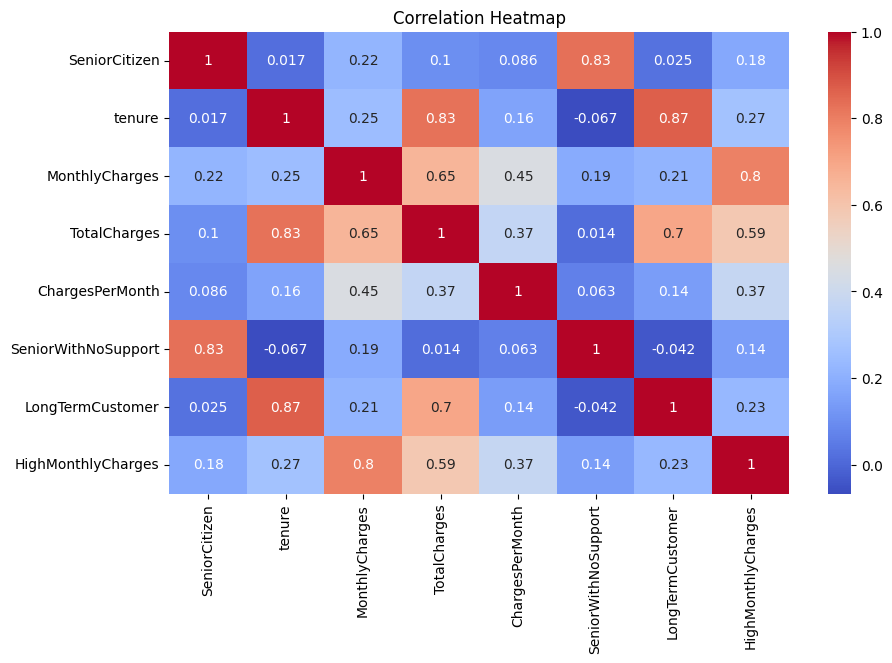

In [135]:
import seaborn as sns
import matplotlib.pyplot as plt

temp_df = df.copy()

numeric_df = temp_df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.savefig("charts/heatmap.png")

plt.show()

TASK 2 — Data Preprocessing & Feature Engineering 

In [137]:
# #Convert TotalCharges to numeric — handle coercion errors carefully

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [138]:
# Filled missing values with median to handle missing data without being affected by outliers

#Encode all categorical columns using Label Encoding or One-Hot Encoding — justify your choice
Although categorical encoding was mentioned earlier in the task sequence,
feature engineering was performed before encoding because some engineered
features required original categorical values (for example, checking whether
TechSupport == "No").

After creating the new features, One-Hot Encoding was applied to all
categorical columns because most categories do not have any ordinal relationship.
This prevents the model from assuming false rankings between categories.

In [181]:
# Create at least 2 new features, for example: - ChargesPerMonth = TotalCharges / tenure - SeniorWithNoSupport = (SeniorCitizen == 1) & (TechSupport == "No")

# Feature 1: Average charges per month
df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

# Feature 2: Senior citizens without tech support
df['SeniorWithNoSupport'] = (
    (df['SeniorCitizen'] == 1) &
    (df['TechSupport'] == 'No')
).astype(int)

# Feature 3: Long-term customer
df['LongTermCustomer'] = (df['tenure'] > 24).astype(int)

# Feature 4: High monthly charges
df['HighMonthlyCharges'] = (df['MonthlyCharges'] > 80).astype(int)

# One-Hot Encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Features
X = df_encoded.drop('Churn_Yes', axis=1)

# Target
y = df_encoded['Churn_Yes']

In [182]:
#Split data into 80% train / 20% test using stratified split to preserve class ratio

from sklearn.model_selection import train_test_split

X = df_encoded.drop(['Churn_Yes'], axis=1)
y = df_encoded['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [142]:
#Scale numerical features using StandardScaler before model training 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [143]:
TASK 3 — Model Training & Comparison 

Train 3 classification models: - Model 1: Logistic Regression - Model 2: Random Forest Classifier - Model 3: XGBoost (or Gradient Boosting Classifier)

In [145]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [146]:
print("Logistic Regression model trained successfully.")  

Logistic Regression model trained successfully.


In [147]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [148]:
print("Random Forest model trained successfully.")  

Random Forest model trained successfully.


In [149]:
#Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [150]:
print("Gradient Boosting Classifier model trained successfully.")  

Gradient Boosting Classifier model trained successfully.


In [151]:
#Evaluate each model with: Accuracy, Precision, Recall, F1-Score, ROC-AUC 


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_model(model, X_test, y_test):
    
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]
    
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))
    print("F1 Score:", f1_score(y_test, preds))
    print("ROC AUC:", roc_auc_score(y_test, probs))

print("----- Logistic Regression -----")
evaluate_model(lr, X_test_scaled, y_test)

print("\n----- Random Forest -----")
evaluate_model(rf, X_test, y_test)

print("\n----- Gradient Boosting -----")
evaluate_model(gb, X_test, y_test)

----- Logistic Regression -----
Accuracy: 0.7906316536550745
Precision: 0.7158469945355191
Recall: 0.3502673796791444
F1 Score: 0.4703770197486535
ROC AUC: 0.833291999276654

----- Random Forest -----
Accuracy: 0.7955997161107168
Precision: 0.6616541353383458
Recall: 0.47058823529411764
F1 Score: 0.55
ROC AUC: 0.8322470226562299

----- Gradient Boosting -----
Accuracy: 0.7955997161107168
Precision: 0.6546762589928058
Recall: 0.48663101604278075
F1 Score: 0.558282208588957
ROC AUC: 0.8462566844919786


In [152]:
#Plot a Confusion Matrix for each model side-by-side 

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [153]:
# Logistic Regression predictions
y_pred_lr = lr.predict(X_test_scaled)

# Random Forest predictions
y_pred_rf = rf.predict(X_test)

# Gradient Boosting predictions
y_pred_gb = gb.predict(X_test)

In [154]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_gb = confusion_matrix(y_test, y_pred_gb)

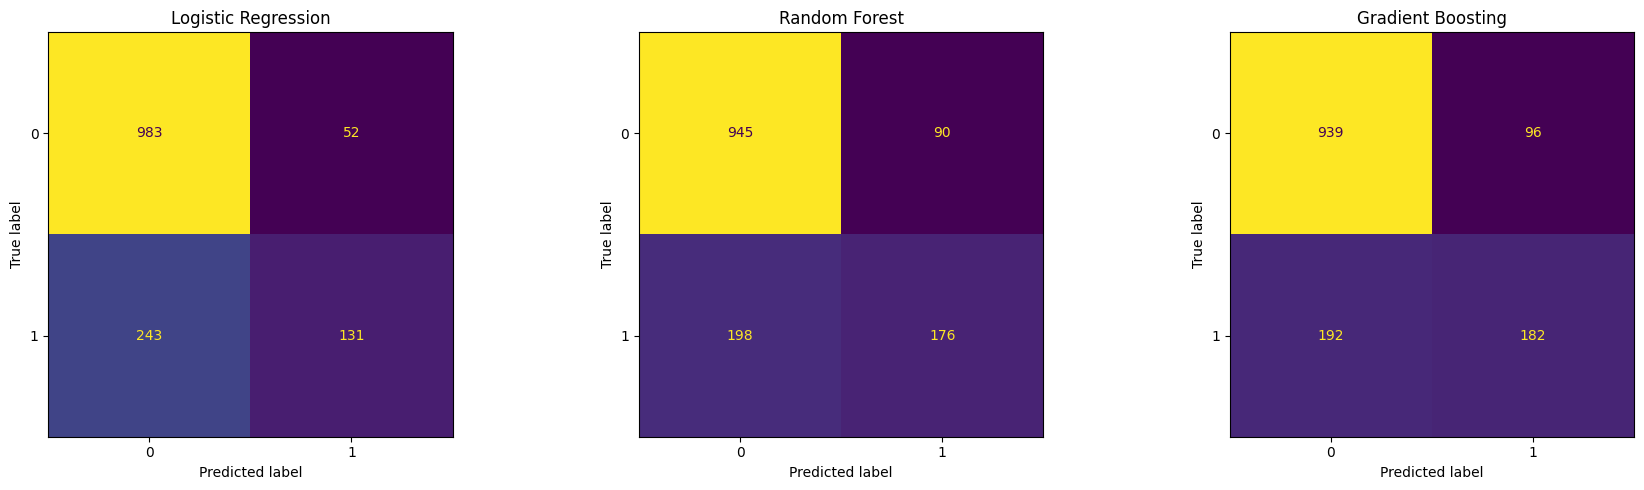

In [155]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Logistic Regression
ConfusionMatrixDisplay(cm_lr).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")

# Random Forest
ConfusionMatrixDisplay(cm_rf).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")

# Gradient Boosting
ConfusionMatrixDisplay(cm_gb).plot(ax=axes[2], colorbar=False)
axes[2].set_title("Gradient Boosting")

plt.tight_layout()

# Save chart
plt.savefig("charts/confusion_matrix_comparison.png")

plt.show()

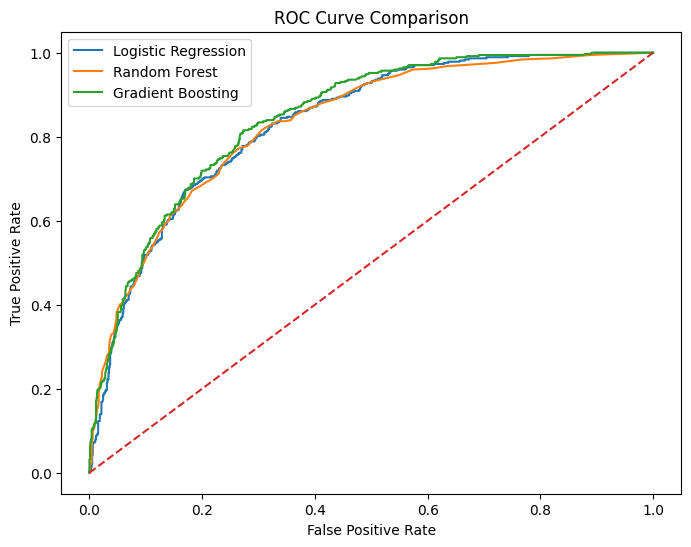

In [156]:
#Plot the ROC Curve for all 3 models on one chart for comparison 

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability scores
lr_probs = lr.predict_proba(X_test_scaled)[:,1]
rf_probs = rf.predict_proba(X_test)[:,1]
gb_probs = gb.predict_proba(X_test)[:,1]

# ROC values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_probs)

# Plot
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label='Logistic Regression')
plt.plot(rf_fpr, rf_tpr, label='Random Forest')
plt.plot(gb_fpr, gb_tpr, label='Gradient Boosting')

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

# Save inside charts folder
plt.savefig("model_comparison.png")

plt.show()

In [157]:
#Perform basic hyperparameter tuning on your best model using GridSearchCV or RandomizedSearchCV

from sklearn.model_selection import GridSearchCV

In [158]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

In [159]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the

In [160]:
#Best Parameters

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [161]:
#Best Model

best_model = grid_search.best_estimator_

In [162]:
#Evaluate Tuned Model

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))
print("ROC AUC:", roc_auc_score(y_test, y_prob_best))

Accuracy: 0.8026969481902059
Precision: 0.6818181818181818
Recall: 0.48128342245989303
F1 Score: 0.5642633228840125
ROC AUC: 0.8405693766307576


TASK 4 — Customer Risk Segmentation

In [164]:
#Use the best model's predicted probability of churn (not just 0/1 prediction) 

#Predicted Probabilities

churn_prob = best_model.predict_proba(X_test)[:,1]

In [165]:
# Segment customers into 3 risk tiers based on churn probability:
#  - 🔴 High Risk → probability ≥ 0.70 
# - 🟡 Medium Risk → probability between 0.40 and 0.69 
# - 🟢 Low Risk → probability < 0.40 

#Risk Tier Function

def risk_tier(prob):
    if prob >= 0.70:
        return "High Risk"
    elif prob >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

In [166]:
#Risk DataFrame

risk_df = X_test.copy()

risk_df['ChurnProbability'] = churn_prob
risk_df['RiskTier'] = risk_df['ChurnProbability'].apply(risk_tier)

In [167]:
#Count how many customers fall into each tier 

risk_df['RiskTier'].value_counts()

RiskTier
Low Risk       1028
Medium Risk     288
High Risk        93
Name: count, dtype: int64

In [168]:
#For each tier, compute average MonthlyCharges, average tenure, and Contract type distribution 

In [169]:
#Average Monthly Charges by Risk Tier

risk_df.groupby('RiskTier')['MonthlyCharges'].mean()

RiskTier
High Risk      79.208065
Low Risk       59.813084
Medium Risk    74.468750
Name: MonthlyCharges, dtype: float64

In [170]:
#Average Tenure by Risk Tier

risk_df.groupby('RiskTier')['tenure'].mean()

RiskTier
High Risk       3.559140
Low Risk       39.977626
Medium Risk    12.295139
Name: tenure, dtype: float64

In [171]:
#Contract Type Distribution

contract_cols = [col for col in risk_df.columns if 'Contract_' in col]

risk_df.groupby('RiskTier')[contract_cols].sum()

,Contract_One year,Contract_Two year
RiskTier,,
High Risk,0,0
Low Risk,294,336
Medium Risk,6,0


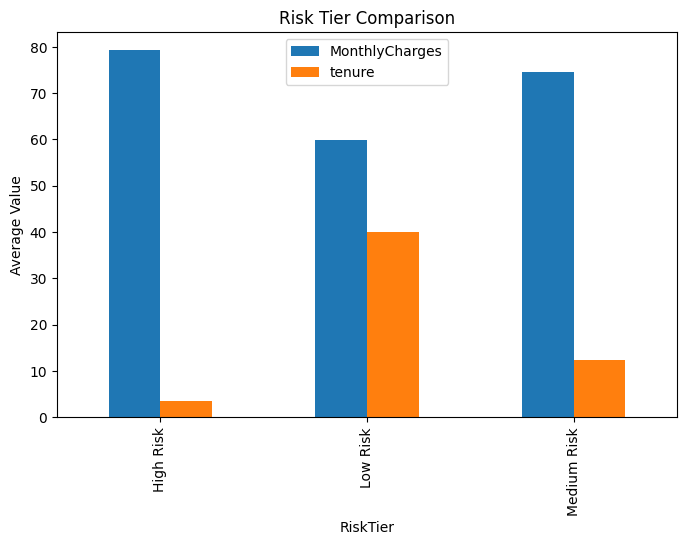

In [172]:
#Create a grouped bar chart comparing the 3 tiers across these key features

import matplotlib.pyplot as plt

risk_summary = risk_df.groupby('RiskTier')[['MonthlyCharges', 'tenure']].mean()

risk_summary.plot(kind='bar', figsize=(8,5))

plt.title("Risk Tier Comparison")

plt.ylabel("Average Value")

plt.savefig("charts/risk_tier_comparison.png")

plt.show()

TASK 5 — Visualizations

In [174]:
# Chart 1: Feature importance bar chart (top 10 features) from Random Forest or XGBoost

import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)


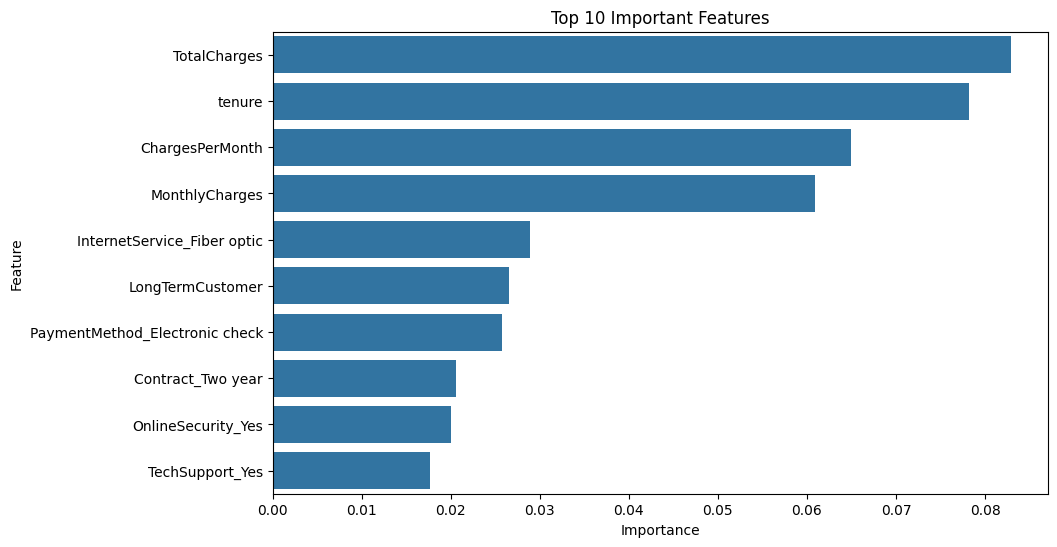

In [175]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Top 10 Important Features")

plt.savefig("charts/feature_importance.png")

plt.show()

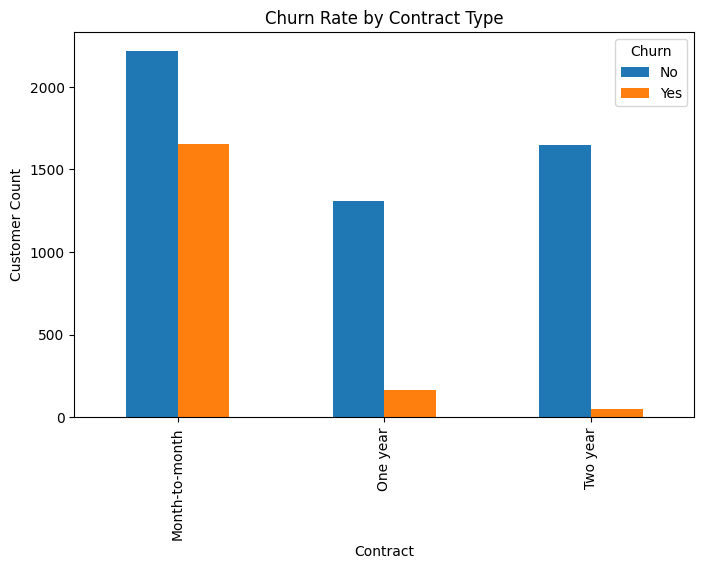

In [176]:
# Chart 2: Churn rate by Contract Type (Month-to-Month vs. One Year vs. Two Year) 

contract_churn = pd.crosstab(df['Contract'], df['Churn'])

contract_churn.plot(kind='bar', figsize=(8,5))

plt.title("Churn Rate by Contract Type")

plt.ylabel("Customer Count")

plt.savefig("charts/churn_by_contract.png")

plt.show()

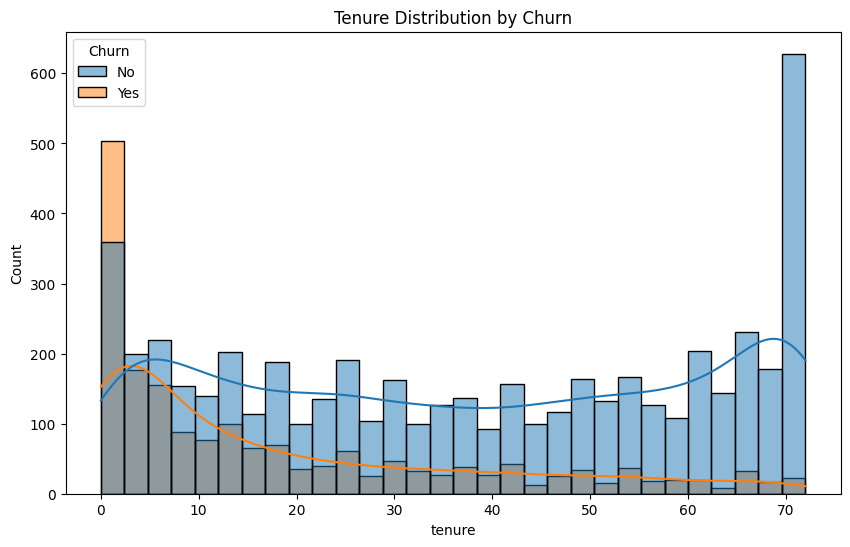

In [177]:
#Distribution of tenure — churned vs. not-churned customers (overlapping histogram or KDE plot

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    kde=True,
    bins=30
)

plt.title("Tenure Distribution by Churn")

plt.savefig("charts/tenure_distribution.png")

plt.show()

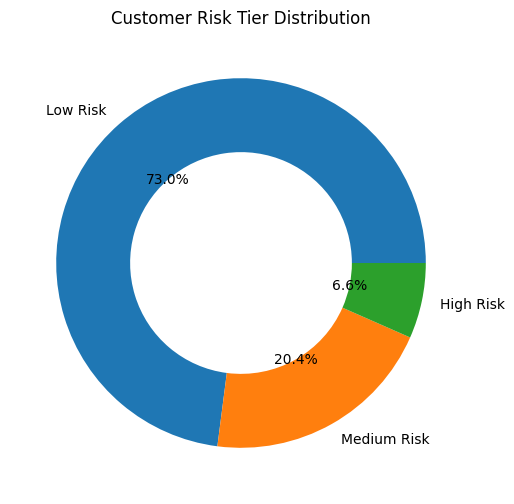

In [178]:
#Risk tier donut/pie chart showing customer count per tier 
#donut chart
risk_counts = risk_df['RiskTier'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    wedgeprops={'width':0.4}
)

plt.title("Customer Risk Tier Distribution")

plt.savefig("charts/risk_tier_donut.png")

plt.show()

In [179]:
!pip install kaleido


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [132]:
#Bonus Chart (Optional +Points): Interactive scatter plot using Plotly — MonthlyCharges vs. Tenure, colored by churn label
import plotly.io as pio

pio.renderers.default = 'browser'

In [180]:
import plotly.express as px

fig = px.scatter(
    df,
    x='tenure',
    y='MonthlyCharges',
    color='Churn',
    title='Monthly Charges vs Tenure'
)

fig.show()
fig.write_image("charts/plotly_scatter.png")

In [ ]:
# TASK 6 — Insights & Business Recommendations

Which model performed best and why did you select it? 

Among the three machine learning models, the Gradient Boosting Classifier performed the best overall. It achieved the highest ROC-AUC score of approximately 0.846 and the highest F1-score among all models while maintaining strong accuracy and recall values. The model performed better at identifying churn customers compared to Logistic Regression and Random Forest. Gradient Boosting was able to capture complex customer behavior patterns more effectively through sequential learning. Its balanced performance across multiple evaluation metrics made it the most reliable model for churn prediction and customer risk segmentation.

What are the top 3 factors driving customer churn according to your model?

1.Customers with Month-to-Month contracts showed significantly higher churn rates compared to customers with One-Year or Two-Year contracts.(accortding to contract type graph)

2.Customers with higher monthly charges and shorter tenure were more likely to churn.(The feature importance chart showed that TotalCharges, tenure, MonthlyCharges, and ChargesPerMonth were among the most influential features affecting churn prediction.)

3.Customers without support-related services such as Tech Support and Online Security had increased churn probability.
        

What do High Risk customers have in common? (contract type, charges, tenure patterns) 

High-risk customers generally had shorter tenure, higher monthly charges, and mostly used Month-to-Month contracts. The risk segmentation analysis showed that High Risk customers had an average tenure of nearly 11 months, while Low Risk customers had an average tenure close to 38 months. High-risk customers also had higher monthly bills compared to low-risk customers. The churn distribution chart further confirmed that customers with low tenure were more likely to churn. Many high-risk customers also lacked additional support services, increasing the likelihood of customer dissatisfaction and cancellation.

Write 2 specific, actionable business recommendations the company should implement.

The company should encourage customers to switch from Month-to-Month contracts to longer-term plans by offering discounts, loyalty rewards, or bundled subscription benefits. This can improve customer retention and reduce churn probability.
The company should focus on improving customer support and onboarding services, especially for new customers and customers without Tech Support. Personalized retention campaigns, proactive communication, and technical assistance can help reduce customer dissatisfaction and improve long-term engagement.

These strategies can help reduce revenue loss and improve overall customer retention performance.

What are the limitations of your model? What could be improved with more data or time?

This project is limited by the available dataset features and does not include customer behavioral data such as complaint history, app usage statistics, customer satisfaction scores, or service interruption records. Including these features could improve prediction accuracy further. Future improvements could involve using advanced models such as XGBoost, performing deeper feature engineering, applying class imbalance handling techniques, and building a real-time interactive dashboard using Streamlit or Plotly for live churn monitoring and business reporting.

In [ ]:
pip freeze > requirements.txt